In [60]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import quad

In [3]:
df = pd.read_excel("probability_distributions_practice_dataset.xlsx")
df.head()

c:\Users\k\Problem-Solving\myenv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\k\Problem-Solving\myenv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,observation_id,height_cm,wait_time_min,delivery_distance_km,purchased,successes_out_of_10,calls_per_hour,monthly_spend_usd
0,1,179.581,9.265,4.242,0,2,3,48.13
1,2,172.263,6.682,13.961,1,3,12,28.01
2,3,180.216,4.080,3.204,1,4,5,222.60
3,4,174.367,18.584,12.518,1,4,5,76.46
4,5,167.733,10.845,6.699,1,3,4,111.96


In [4]:
df.shape

(1000, 8)

# Continuous Values distributions

## Normal (Gaussian) Distribution

#### Histogram

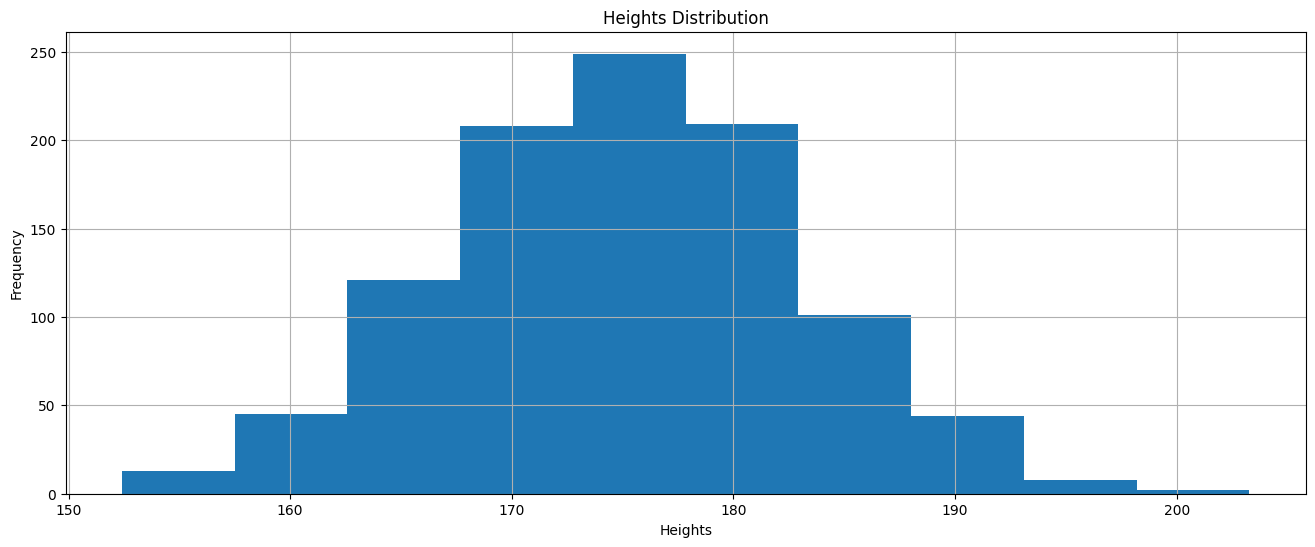

In [5]:
plt.figure(figsize=(16, 6))
plt.hist(
    df['height_cm']
)
plt.title("Heights Distribution")
plt.xlabel("Heights")
plt.ylabel("Frequency")
plt.grid()
plt.show()

#### Comparing mean and median

In [6]:
mean_height = df['height_cm'].mean()
mean_height

np.float64(175.131052)

In [7]:
median_height = df['height_cm'].median()
median_height

np.float64(175.19150000000002)

#### Skewness

In [8]:
def skewness(df):
    mean = df.mean()
    std = df.std(ddof=0)

    sum_values = 0
    for i in df:
        sum_values += ((i - mean) / std)**3

    return sum_values / len(df)

In [9]:
skewness_height = skewness(df['height_cm'])
skewness_height

np.float64(0.06037173469563501)

#### Kurtosis

In [10]:
def fisher_kurtosis(df):
    mean = df.mean()
    std = df.std(ddof=0)
    sum_values = 0
    for i in df:
        sum_values += ((i - mean) / std) ** 4 
    return sum_values / len(df) - 3




In [11]:
fisher_kurtosis_height = fisher_kurtosis(df['height_cm'])
fisher_kurtosis_height

np.float64(-0.012759181070006065)

#### 68-95-99.7 rule

In [12]:
mean_height = df['height_cm'].mean()
std_height = df['height_cm'].std()
print(mean_height)
print(std_height)

175.131052
7.894139077002828


In [13]:
lower_1 = mean_height - std_height
upper_1 = mean_height + std_height

lower_2 = mean_height - 2 * std_height
upper_2 = mean_height + 2 * std_height

lower_3 = mean_height - 3 * std_height
upper_3 = mean_height + 3 * std_height

print(f"1-standard deviation lower boundary: {lower_1}")
print(f"1-standard deviation upper boundary: {upper_1}")
print(f"2-standard deviation lower boundary: {lower_2}")
print(f"2-standard deviation upper boundary: {upper_2}")
print(f"3-standard deviation lower boundary: {lower_3}")
print(f"3-standard deviation upper boundary: {upper_3}")

1-standard deviation lower boundary: 167.2369129229972
1-standard deviation upper boundary: 183.02519107700283
2-standard deviation lower boundary: 159.34277384599434
2-standard deviation upper boundary: 190.91933015400568
3-standard deviation lower boundary: 151.44863476899152
3-standard deviation upper boundary: 198.8134692310085


In [14]:
within_1 = len(df[(df['height_cm'] > lower_1) & (df['height_cm'] < upper_1)]) / len(df) * 100
within_2 = len(df[(df['height_cm'] > lower_2) & (df['height_cm'] < upper_2)]) / len(df) * 100
within_3 = len(df[(df['height_cm'] > lower_3) & (df['height_cm'] < upper_3)]) / len(df) * 100

print(f"The percentage of value within 1 STD: {within_1}")
print(f"The percentage of value within 2 STD: {within_2}")
print(f"The percentage of value within 3 STD: {within_3}")

The percentage of value within 1 STD: 69.1
The percentage of value within 2 STD: 95.1
The percentage of value within 3 STD: 99.8


### PDF

Question: `P(170 ≤ X ≤ 180)`

In [15]:
import numpy as np
from scipy.stats import norm

# Select data
height = df['height_cm'].dropna()

# 1. Estimate parameters
mu = height.mean()
sigma = height.std(ddof=0)

print("Mean:", mu)
print("Standard deviation:", sigma)

# 2. PDF density at a specific point
density_170 = norm.pdf(
    170,
    loc=mu,
    scale=sigma
)

density_180 = norm.pdf(
    180,
    loc=mu,
    scale=sigma
)

print("Density at 170:", density_170)
print("Density at 180:", density_180)

# 3. CDF values
cdf_170 = norm.cdf(
    170,
    loc=mu,
    scale=sigma
)

cdf_180 = norm.cdf(
    180,
    loc=mu,
    scale=sigma
)

print("P(X <= 170):", cdf_170)
print("P(X <= 180):", cdf_180)

# 4. Probability between 170 and 180
prob_170_180 = cdf_180 - cdf_170

print("P(170 <= X <= 180):", prob_170_180)
print("Percentage:", prob_170_180 * 100)

Mean: 175.131052
Standard deviation: 7.89019102020325
Density at 170: 0.04092521375712278
Density at 180: 0.04179585395848834
P(X <= 170): 0.2577467411229545
P(X <= 180): 0.7314119009118575
P(170 <= X <= 180): 0.473665159788903
Percentage: 47.3665159788903


#### Conclution:
- **Visualization** - Histogram shows that that the distribution has one central peack around 175-80, decreases toward both tails, looks a bell-like shape
- **Comparing mean and mode** - mean_heaight=175.14 and media_heigh=175.19, mean≈median
- **Skewness** - skewness = 0.06 , skewness ≈ 0
- **Fisher kurtosis** - fisher_kurtosis = -0.01, fisher_kurtosis ≈ 0 
- **68-95-99.7 rule** - 69% values in 1 STD, 95% values in 2 STD, 99.8% values in 3 STD

## Exponential Distribution

### Visualization Waiting-time Distribution

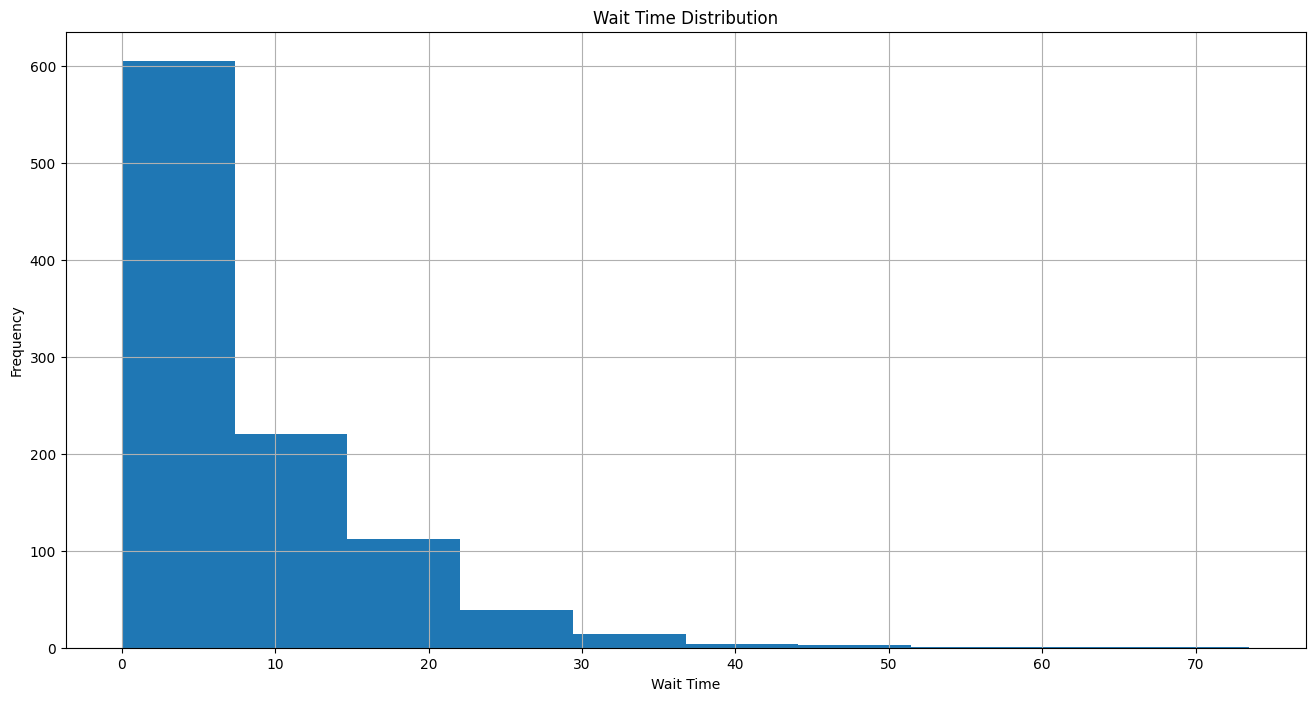

In [16]:
plt.figure(figsize=(16, 8))
plt.hist(
    df['wait_time_min']
)
plt.title("Wait Time Distribution")
plt.xlabel("Wait Time")
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Descriptive statistics 

In [17]:
df['wait_time_min'].describe()

count    1000.000000
mean        8.187564
std         8.229124
min         0.005000
25%         2.486000
50%         5.374500
75%        11.942000
max        73.507000
Name: wait_time_min, dtype: float64

### Non-negative Values

In [18]:
sum(df['wait_time_min'] < 0)

0

### Skewness

In [19]:
def skewness(df):
    mean = df.mean()
    std = df.std(ddof=0)
    n = len(df)

    sum_values = 0
    for i in df:
        sum_values += ((i - mean) / std) ** 3

    return sum_values / n

wait_time_skewness = skewness(df['wait_time_min'])
wait_time_skewness

np.float64(2.20869680498422)

### λ parameter

In [20]:
lambda_wait_time = 1 / df['wait_time_min'].mean()
lambda_wait_time

np.float64(0.12213644986469724)

on average λ=0.125 events happen in per minute, 0.125*60=7.5 events happen per hour

### Expected value 

In [21]:
expected_wait_time = 1 / lambda_wait_time
expected_wait_time

np.float64(8.187564)

average waiting time for the next event is E[X]=1/λ=8.2 minutes

### Variance

In [22]:
variance_wait_time = 1 / (lambda_wait_time ** 2)
variance_wait_time

np.float64(67.036204254096)

### Standard Deviation

In [23]:
std_wait_time = 1 / lambda_wait_time
std_wait_time

np.float64(8.187564)

### Probability Density Function (PDF)

`P(10 ≤ X ≤ 20)` - what is the probabilit of waiting time that it will be between 10 and 20

In [ ]:
lambda_wait_time = 1 / df['wait_time_min'].mean()

prob_10_20 = (
    np.exp(-lambda_wait_time * 10) - np.exp(-lambda_wait_time * 20)
)
prob_10_20

np.float64(0.2079042864726816)

## Uniform Distribution 

In [25]:
df['delivery_distance_km'].head()

0     4.242
1    13.961
2     3.204
3    12.518
4     6.699
Name: delivery_distance_km, dtype: float64

### Visualization 

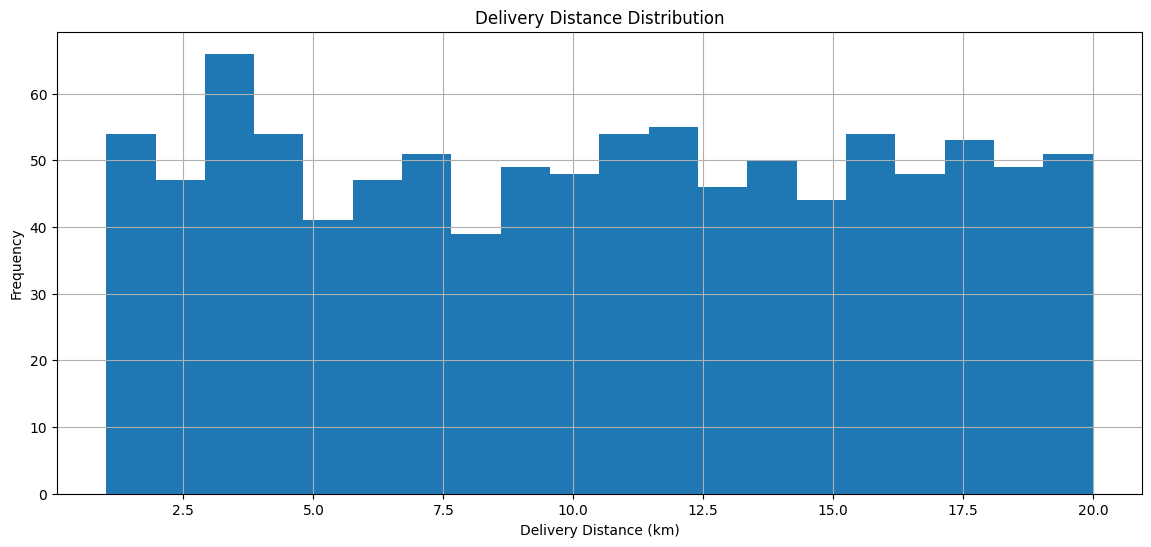

In [26]:
plt.figure(figsize=(14, 6))
plt.hist(
    df['delivery_distance_km'],
    bins=20
)
plt.title("Delivery Distance Distribution")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Frequency")
plt.grid()

plt.show()

### Descriptibe Statistics

In [27]:
df['delivery_distance_km'].describe()

count    1000.000000
mean       10.447577
std         5.550935
min         1.015000
25%         5.601500
50%        10.596000
75%        15.297750
max        19.989000
Name: delivery_distance_km, dtype: float64

### Range

In [28]:
a = df['delivery_distance_km'].min()
b = df['delivery_distance_km'].max()

print("Minimum:", a)
print("Maximum:", b)

Minimum: 1.015
Maximum: 19.989


### Median and Mean

In [29]:
mean_distance = df['delivery_distance_km'].mean()
median_distance = df['delivery_distance_km'].median()

print(f"Mean Distance: {mean_distance}")
print(f"Median Distance: {median_distance}")

Mean Distance: 10.447577
Median Distance: 10.596


### Variance

In [30]:
variance_distance = ((b - a) ** 2 ) / 12 
variance_distance

np.float64(30.001056333333334)

### Statndard Deviation

In [31]:
std_distance = np.sqrt(variance_distance)
std_distance

np.float64(5.47732200380198)

### Uniform PDF

Suppose We want to know  `P(2 ≤ X ≤ 6)`

In [32]:
density = 1 / (b - a)
density

np.float64(0.05270369979972594)

In [33]:
interval_2_6km = 6 - 2
area = density * interval_2_6km
area

np.float64(0.21081479919890375)

there is 21% probability dinstance will be a number between 2 and 6

# Discreate Values Distributions

## Bernoulli Distribution 

In [34]:
df.head()

,observation_id,height_cm,wait_time_min,delivery_distance_km,purchased,successes_out_of_10,calls_per_hour,monthly_spend_usd
0,1,179.581,9.265,4.242,0,2,3,48.13
1,2,172.263,6.682,13.961,1,3,12,28.01
2,3,180.216,4.080,3.204,1,4,5,222.60
3,4,174.367,18.584,12.518,1,4,5,76.46
4,5,167.733,10.845,6.699,1,3,4,111.96


### checking possible values

In [35]:
df['purchased'].unique()

array([0, 1])

### Checking values frequencies

In [36]:
df['purchased'].value_counts()

purchased
1    663
0    337
Name: count, dtype: int64

### Estimate p

In [37]:
successed_purchases = sum(df['purchased'] == 1) / len(df)
successed_purchases

p = successed_purchases

### P(X=1) and p(X=0)

In [38]:
prob_1 = successed_purchases
prob_0 = 1 - successed_purchases

print(f"Probability of purchase 1: {prob_1}")
print(f"Probability of purchase 0: {prob_0}")

Probability of purchase 1: 0.663
Probability of purchase 0: 0.33699999999999997


### Expected Value

`E[X] = p`

In [39]:
expected_purchase = 1 * prob_1 + 0 * prob_0 
expected_purchase

0.663

### Variance

`Var(X) = p * (1 - p)`

In [40]:
variance_purchase = p * (1 - p)
variance_purchase

0.223431

### Standard Deviation 

In [41]:
std_purchase = np.sqrt(variance_purchase)
std_purchase

np.float64(0.4726848844632119)

### PMF (Probability Mass Function)

In [42]:
p

0.663

In [43]:
x = 1

pmf_1 = (p ** x) * ((1 - p)**(1 - x))
pmf_1

0.663

In [44]:
x = 0
pmf_0 = (p ** x) * ((1 - p) ** (1 - x))

pmf_0

0.33699999999999997

## Binomial Distribution 

In [55]:
df.head()

,observation_id,height_cm,wait_time_min,delivery_distance_km,purchased,successes_out_of_10,calls_per_hour,monthly_spend_usd
0,1,179.581,9.265,4.242,0,2,3,48.13
1,2,172.263,6.682,13.961,1,3,12,28.01
2,3,180.216,4.080,3.204,1,4,5,222.60
3,4,174.367,18.584,12.518,1,4,5,76.46
4,5,167.733,10.845,6.699,1,3,4,111.96


In [45]:
successes = df['successes_out_of_10']
successes.head()

0    2
1    3
2    4
3    4
4    3
Name: successes_out_of_10, dtype: int64

In [46]:
successes.unique()

array([2, 3, 4, 5, 6, 9, 7, 1, 8, 0])

In [47]:
successes.value_counts().sort_index()

successes_out_of_10
0      8
1     49
2    122
3    197
4    249
5    215
6    107
7     37
8     12
9      4
Name: count, dtype: int64

### Visualization

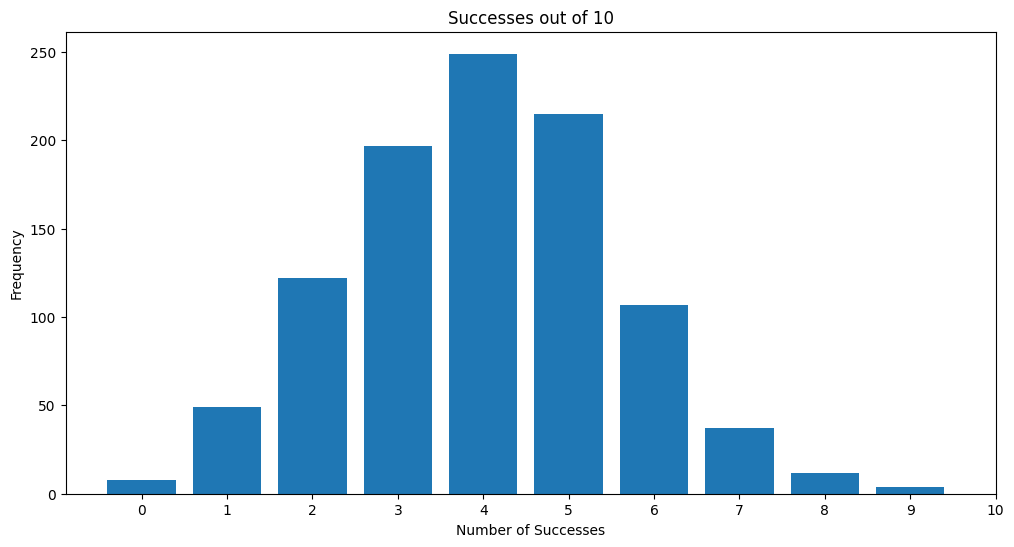

In [48]:

frequency = successes.value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.bar(
    frequency.index,
    frequency.values
)

plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.title("Successes out of 10")

plt.xticks(range(11))
plt.show()

### n = number of trails

In [49]:
n = 10

### Estimating p

In [50]:
mean_success = successes.mean()
p = mean_success / n 
p

np.float64(0.3988)

### Expected Value E[X] = n * p

In [51]:
expected_value = n * p
expected_value

np.float64(3.988)

### Variance 

In [52]:
theoretical_variance = (
    n * p * (1 - p)
)
theoretical_variance

np.float64(2.3975855999999998)

In [53]:
sample_variance = successes.var()
sample_variance

np.float64(2.52438038038038)

### Standard Deviation

In [54]:
theoretical_std = np.sqrt(theoretical_variance)
theoretical_std

np.float64(1.5484138981551412)

### PMF (Probability Mass Function)

`P(X = k) = (n, k) · pᵏ · (1 - p)ⁿ⁻ᵏ`
- Question: `P(X = 9) = ?`

In [56]:
n

10

In [57]:
p

np.float64(0.3988)

In [58]:
k = 9

In [63]:
combination = (
    math.factorial(n) 
    / 
    (math.factorial(k) * math.factorial(n - k))
)
p_9 =combination * (p ** 9) * ((1 - p)** (n - k))
p_9

np.float64(0.0015339645341424057)

In [64]:
p_9 = p_9 * 100
p_9

np.float64(0.15339645341424057)

There is approximately a 0.153% probability of getting exactly 9 successes out of 10 trials.

## Poisson Distribution

In [65]:
df.head()

,observation_id,height_cm,wait_time_min,delivery_distance_km,purchased,successes_out_of_10,calls_per_hour,monthly_spend_usd
0,1,179.581,9.265,4.242,0,2,3,48.13
1,2,172.263,6.682,13.961,1,3,12,28.01
2,3,180.216,4.080,3.204,1,4,5,222.60
3,4,174.367,18.584,12.518,1,4,5,76.46
4,5,167.733,10.845,6.699,1,3,4,111.96


In [79]:
df['calls_per_hour'].describe()

count    1000.000000
mean        4.971000
std         2.265235
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        13.000000
Name: calls_per_hour, dtype: float64

In [69]:
calls_per_hour = df['calls_per_hour']
frequency_calls = calls_per_hour.value_counts()
frequency_calls

calls_per_hour
4     189
5     169
6     155
3     139
7      84
2      81
8      56
9      42
1      39
10     27
0       7
11      7
12      4
13      1
Name: count, dtype: int64

### Visualization

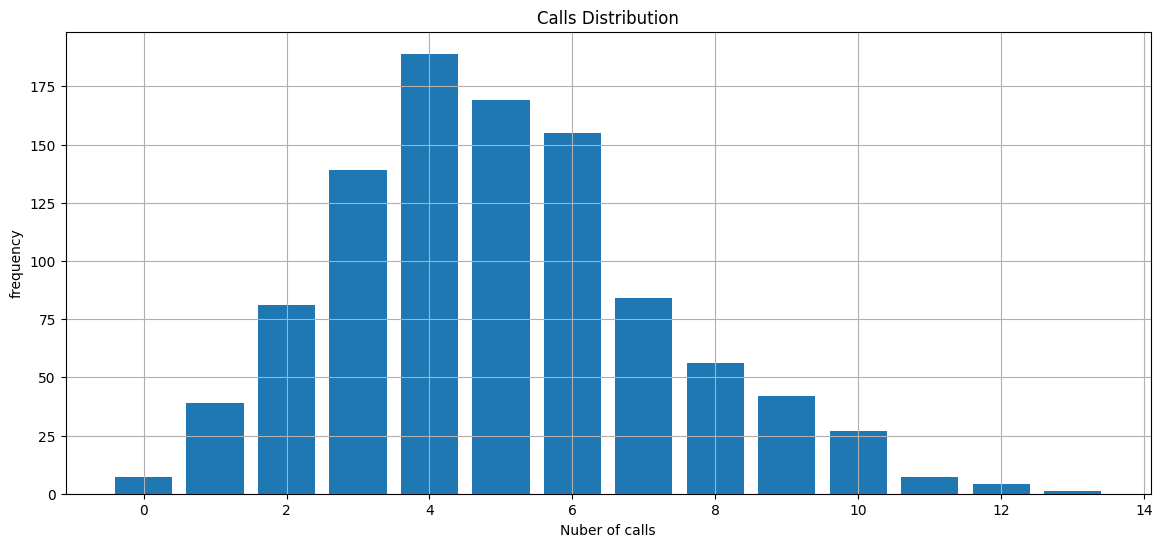

In [72]:
plt.figure(figsize=(14, 6))
plt.bar(
    frequency_calls.index,
    frequency_calls.values
)
plt.title("Calls Distribution")
plt.ylabel("frequency")
plt.xlabel("Nuber of calls")
plt.grid()
plt.show()

### λ = average number of calls per hour

In [73]:
param_lambda = calls_per_hour.mean()
param_lambda

np.float64(4.971)

### Mean number calls

In [74]:
calls_per_hour.mean()

np.float64(4.971)

### Expected value 

In [75]:
expected_value_of_call = param_lambda
expected_value_of_call

np.float64(4.971)

### Variance

In [76]:
variacne_of_call = param_lambda
variacne_of_call

np.float64(4.971)

### Standard Deviation 

In [78]:
std_call = np.sqrt(variacne_of_call)
std_call

np.float64(2.2295739503322154)

### PMF (Probability Mass Function)

 - Formula: `P(X = k) = (e⁻λ · λᵏ) / k!`
- Quesrtion - `P(X = 10) = ?`

In [80]:
param_lambda

np.float64(4.971)

In [81]:
k = 10

In [85]:
p_10 = np.exp(-param_lambda) * (param_lambda ** k) / math.factorial(k)
p_10 = p_10 * 100
p_10

np.float64(1.7611515485371474)

If the average number of events per interval is \(\lambda=4.971\), then the probability of observing exactly 10 events in one interval is about 1.76%.